#MULTIPLE LINEAR REGRESSION

Assignment Task:
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes


Dataset Description:
The dataset consists of the following variables:
Age: Age in years
KM: Accumulated Kilometers on odometer
FuelType: Fuel Type (Petrol, Diesel, CNG)
HP: Horse Power
Automatic: Automatic ( (Yes=1, No=0)
CC: Cylinder Volume in cubic centimeters
Doors: Number of doors
Weight: Weight in Kilograms
Quarterly_Tax: 
Price: Offer Price in EUROs


Tasks:
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [218]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [219]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [220]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [221]:
df.shape

(1436, 11)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [223]:
### missing data
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

no missing data to handle

In [224]:
### handling duplicates
df.duplicated().sum()

np.int64(1)

In [225]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [226]:
df.duplicated().sum()

np.int64(0)

In [227]:
df.boxplot()

<Axes: >

In [228]:
### outliers capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]=df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

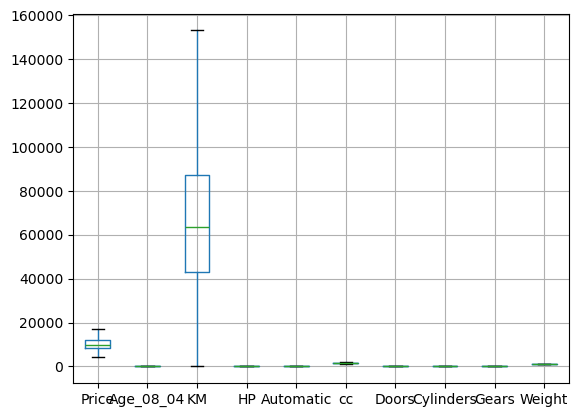

In [230]:
df.boxplot()
plt.show()

 feature selection

In [231]:
target= df[['Price']]
features= df.drop(columns=['Price'])

In [232]:
target.head()

,Price
0,13500.0
1,13750.0
2,13950.0
3,14950.0
4,13750.0


In [233]:
features.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
1,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
2,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
3,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5
4,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5


In [236]:
features = pd.get_dummies(features, drop_first=True)  # e.g., Fuel_Type


In [237]:
from sklearn.feature_selection import f_regression

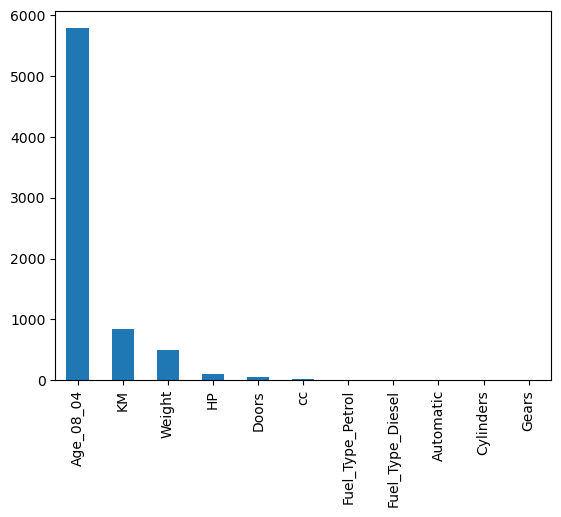

In [238]:
f_reg= f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [239]:
#### Variance_Inflation_factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [240]:
features.values

array([[23.0, 46986.0, 90.0, ..., 1152.5, True, False],
       [23.0, 72937.0, 90.0, ..., 1152.5, True, False],
       [24.0, 41711.0, 90.0, ..., 1152.5, True, False],
       ...,
       [71.0, 17016.0, 86.0, ..., 1015.0, False, True],
       [70.0, 16916.0, 86.0, ..., 1015.0, False, True],
       [76.0, 1.0, 110.0, ..., 1114.0, False, True]], dtype=object)

In [241]:
for i in range(len(features.columns)):
    print(i)

0
1
2
3
4
5
6
7
8
9
10


In [242]:
features.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
1,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
2,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
3,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
4,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False


2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [243]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 11)
(287, 11)
(1148, 1)
(287, 1)


3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [244]:
from sklearn.preprocessing import StandardScaler
std_sca= StandardScaler()

In [245]:
# Model 1: all features
lin_reg1 = LinearRegression()
lin_reg1.fit(x_train, y_train)

LinearRegression()

In [246]:
# Predictions
y_pred1 = lin_reg1.predict(x_test)


In [247]:
lin_reg1.coef_

array([[-1.04955438e+02, -1.48577449e-02,  2.99935241e+01,
        -2.48689958e-14, -2.73092835e+00, -1.28407174e+02,
        -5.68434189e-14,  0.00000000e+00,  2.56397343e+01,
         9.46078098e+02,  1.00930530e+03]])

In [248]:
lin_reg1.intercept_

array([-9284.78442972])

4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [249]:
#### Testing_Validation
y_pred1=lin_reg1.predict(x_test)
r2_score(y_test,y_pred1)

0.8504842513871484

In [250]:
r_sq=r2_score(y_test,y_pred1)
r_sq

0.8504842513871484

In [251]:
x_test.shape

(287, 11)

In [252]:
y_test.shape

(287, 1)

In [287]:
N=287
k= 11

In [288]:
### adj_r2
adj_r2= 1-(((1-r_sq)*(N-1))/(N-k-1))
adj_r2

0.8445036214426344

In [289]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
#### mean_squared_error
mse= mean_squared_error(y_test,y_pred1)
mse

1275108.7184944444

In [290]:
#### RMSE(Root_Mean_Squared_Error)
rmse= np.sqrt(mse)
rmse

np.float64(1129.2071193959257)

In [291]:
#### Mean_Absolute_Error
mae= mean_absolute_error(y_test,y_pred1)
mae

874.1130422099012

In [292]:
#### Mean_Absolute_Percentage_Error
mape= mean_absolute_percentage_error(y_test,y_pred1)*100
mape

8.801752998108077

In [293]:
# Evaluation
print("Model 1 - All Features")
print("Coefficients:", dict(zip(x_train.columns, lin_reg1.coef_)))
print("Intercept:", lin_reg1.intercept_)
print("R^2 score:", r2_score(y_test, y_pred1))
print("MSE:", mean_squared_error(y_test, y_pred1))

Model 1 - All Features
Coefficients: {'Age_08_04': array([-1.04955438e+02, -1.48577449e-02,  2.99935241e+01, -2.48689958e-14,
       -2.73092835e+00, -1.28407174e+02, -5.68434189e-14,  0.00000000e+00,
        2.56397343e+01,  9.46078098e+02,  1.00930530e+03])}
Intercept: [-9284.78442972]
R^2 score: 0.8504842513871484
MSE: 1275108.7184944444


In [295]:
### model 2
### only numeric features
## selecting the numerical columns
df_numerical = df.select_dtypes(include = 'number')
df_numerical.head()


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5


In [296]:
target_num= df_numerical[['Price']]
features_num= df_numerical.drop(columns=['Price'])

In [297]:
features_num.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5
1,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5
2,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5
3,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5
4,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5


In [298]:
from sklearn.feature_selection import f_regression

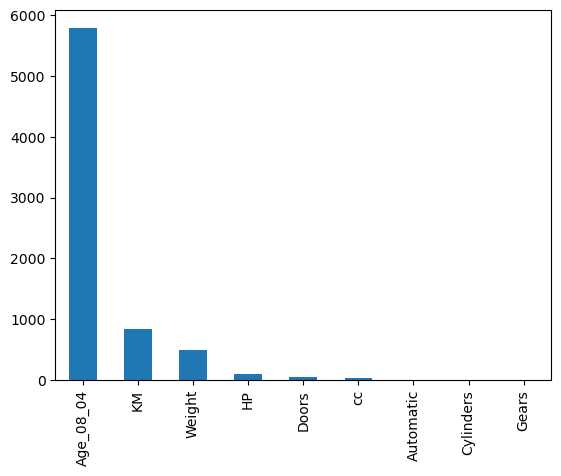

In [299]:
f_reg= f_regression(features_num,target_num)
pd.Series(f_reg[0],index=features_num.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [300]:
#### Variance_Inflation_factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [301]:
features_num.values

array([[2.3000e+01, 4.6986e+04, 9.0000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.1525e+03],
       [2.3000e+01, 7.2937e+04, 9.0000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.1525e+03],
       [2.4000e+01, 4.1711e+04, 9.0000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.1525e+03],
       ...,
       [7.1000e+01, 1.7016e+04, 8.6000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.0150e+03],
       [7.0000e+01, 1.6916e+04, 8.6000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.0150e+03],
       [7.6000e+01, 1.0000e+00, 1.1000e+02, ..., 4.0000e+00, 5.0000e+00,
        1.1140e+03]])

In [302]:
features_num.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5
1,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5
2,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5
3,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5
4,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5


In [303]:
## splitting data
x_train_num,x_test_num,y_train_num,y_test_num=train_test_split(features_num,target_num,test_size=0.2,random_state=42)
print(x_train_num.shape)
print(x_test_num.shape)
print(y_train_num.shape)
print(y_test_num.shape)

(1148, 9)
(287, 9)
(1148, 1)
(287, 1)


In [304]:
## building model2(lin_reg2)
from sklearn.preprocessing import StandardScaler
std_sca= StandardScaler()

In [305]:
lin_reg2 = LinearRegression()
lin_reg2.fit(x_train_num, y_train_num)

LinearRegression()

In [306]:
## predictions
y_pred2 = lin_reg2.predict(x_test_num)

In [307]:
lin_reg2.coef_

array([[-1.04672006e+02, -1.58213240e-02,  2.93538575e+01,
         8.02913291e-13, -2.64871356e+00, -1.18932453e+02,
         0.00000000e+00,  0.00000000e+00,  2.48428788e+01]])

In [308]:
lin_reg2.intercept_

array([-7494.12421533])

In [309]:
#### Testing_Validation
y_pred2=lin_reg2.predict(x_test_num)
r2_score(y_test_num,y_pred2)

0.8460197860710085

In [310]:
x_test_num.shape

(287, 9)

In [311]:
y_test_num.shape

(287, 1)

In [313]:
N=287
k=9

In [329]:
### adj_r2
adj_r2_num= 1-(((1-r_sq)*(N-1))/(N-k-1))
adj_r2_num

0.8456263389773446

In [320]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
#### mean_squared_error
mse_num= mean_squared_error(y_test_num,y_pred2)
mse_num

1313182.8257429488

In [321]:
#### RMSE(Root_Mean_Squared_Error)
rmse_num= np.sqrt(mse_num)
rmse_num

np.float64(1145.9418945753528)

In [322]:
#### Mean_Absolute_Error
mae_num= mean_absolute_error(y_test_num,y_pred2)
mae_num

886.6777310327179

In [323]:
#### Mean_Absolute_Percentage_Error
mape_num= mean_absolute_percentage_error(y_test_num,y_pred2)*100
mape_num

8.91643273095937

In [324]:
# Evaluation
print("Model 2 - Only numerical Features")
print("Coefficients num:", dict(zip(x_train_num.columns, lin_reg2.coef_)))
print("Intercept num:", lin_reg2.intercept_)
print("R^2 score num:", r2_score(y_test_num, y_pred2))
print("MSE num:", mean_squared_error(y_test_num, y_pred2))

Model 2 - Only numerical Features
Coefficients num: {'Age_08_04': array([-1.04672006e+02, -1.58213240e-02,  2.93538575e+01,  8.02913291e-13,
       -2.64871356e+00, -1.18932453e+02,  0.00000000e+00,  0.00000000e+00,
        2.48428788e+01])}
Intercept num: [-7494.12421533]
R^2 score num: 0.8460197860710085
MSE num: 1313182.8257429488


5.Apply Lasso and Ridge methods on the model.

In [326]:
# Lasso Regression for model1
from sklearn.linear_model import Lasso

In [328]:
lasso = Lasso(alpha=0.1)  # alpha = regularization strength
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)


In [333]:
print("\n----- Lasso Regression for model1-----")
print("Coefficients from Lasso:", dict(zip(x_train.columns, lasso.coef_)))
print("Intercept from Lasso:", lasso.intercept_)
print("R^2 score from Lasso:", r2_score(y_test, y_pred_lasso))
print("MSE from Lasso:", mean_squared_error(y_test, y_pred_lasso))


----- Lasso Regression for model1-----
Coefficients from Lasso: {'Age_08_04': np.float64(-104.96763674310711), 'KM': np.float64(-0.014876576823552012), 'HP': np.float64(29.668372193462318), 'Automatic': np.float64(0.0), 'cc': np.float64(-2.70338275098824), 'Doors': np.float64(-128.26944718536052), 'Cylinders': np.float64(0.0), 'Gears': np.float64(0.0), 'Weight': np.float64(25.63226630116028), 'Fuel_Type_Diesel': np.float64(908.9936395233658), 'Fuel_Type_Petrol': np.float64(990.4468551009469)}
Intercept from Lasso: [-9264.84349911]
R^2 score from Lasso: 0.8504277816228829
MSE from Lasso: 1275590.3071525919


In [340]:
# Lasso regression to model2
lasso_num = Lasso(alpha=0.1)  # alpha = regularization strength
lasso_num.fit(x_train_num, y_train_num)
y_pred2_lasso = lasso_num.predict(x_test_num)

In [341]:
print("\n----- Lasso Regression for model2-----")
print("Coefficients for model2from Lasso:", dict(zip(x_train_num.columns, lasso_num.coef_)))
print("Intercept for model2 from Lasso:", lasso_num.intercept_)
print("R^2 score for model2from Lasso:", r2_score(y_test_num, y_pred2_lasso))
print("MSE for model2 from Lasso:", mean_squared_error(y_test_num, y_pred2_lasso))


----- Lasso Regression for model2-----
Coefficients for model2from Lasso: {'Age_08_04': np.float64(-104.67273706076851), 'KM': np.float64(-0.015821816067918434), 'HP': np.float64(29.351187736069704), 'Automatic': np.float64(0.0), 'cc': np.float64(-2.6483317964467163), 'Doors': np.float64(-118.7878212798149), 'Cylinders': np.float64(0.0), 'Gears': np.float64(0.0), 'Weight': np.float64(24.84009097039707)}
Intercept for model2 from Lasso: [-7491.9789096]
R^2 score for model2from Lasso: 0.8460232383213663
MSE for model2 from Lasso: 1313153.384064928


Ridge Regression

In [337]:
# Ridge Regression
from sklearn.linear_model import Ridge

In [338]:
ridge = Ridge(alpha=1.0)  # alpha = regularization strength
ridge.fit(x_train, y_train)
y_pred_ridge = ridge.predict(x_test)

In [339]:
print("\n----- Ridge Regression for model1-----")
print("Coefficients of Ridge:", dict(zip(x_train.columns, ridge.coef_)))
print("Intercept of Ridge:", ridge.intercept_)
print("R^2 score of Ridge:", r2_score(y_test, y_pred_ridge))
print("MSE of Ridge:", mean_squared_error(y_test, y_pred_ridge))


----- Ridge Regression for model1-----
Coefficients of Ridge: {'Age_08_04': np.float64(-105.02193601498129), 'KM': np.float64(-0.014984316192902428), 'HP': np.float64(28.014985132806316), 'Automatic': np.float64(0.0), 'cc': np.float64(-2.563673006443156), 'Doors': np.float64(-128.15086079367344), 'Cylinders': np.float64(0.0), 'Gears': np.float64(0.0), 'Weight': np.float64(25.59653440160937), 'Fuel_Type_Diesel': np.float64(705.8278650520763), 'Fuel_Type_Petrol': np.float64(879.2744780370438)}
Intercept of Ridge: [-9147.52263164]
R^2 score of Ridge: 0.8500499521409742
MSE of Ridge: 1278812.534048124


In [342]:
# Ridge regression for model2
ridge_num = Ridge(alpha=1.0)  # alpha = regularization strength
ridge_num.fit(x_train_num, y_train_num)
y_pred2_ridge = ridge_num.predict(x_test_num)

In [343]:
print("\n----- Ridge Regression for model2-----")
print("Coefficients for model2 of Ridge:", dict(zip(x_train_num.columns, ridge_num.coef_)))
print("Intercept for model2 of Ridge:", ridge_num.intercept_)
print("R^2 for model2 score of Ridge:", r2_score(y_test_num, y_pred2_ridge))
print("MSE for model2 of Ridge:", mean_squared_error(y_test_num, y_pred2_ridge))


----- Ridge Regression for model2-----
Coefficients for model2 of Ridge: {'Age_08_04': np.float64(-104.67268311651733), 'KM': np.float64(-0.015821696743552268), 'HP': np.float64(29.351769071079413), 'Automatic': np.float64(0.0), 'cc': np.float64(-2.6483782206513937), 'Doors': np.float64(-118.78651029862466), 'Cylinders': np.float64(0.0), 'Gears': np.float64(0.0), 'Weight': np.float64(24.840291395106522)}
Intercept for model2 of Ridge: [-7492.19588629]
R^2 for model2 score of Ridge: 0.8460229527210434
MSE for model2 of Ridge: 1313155.8197378598


Interview Questions:

1.What is Normalization & Standardization and how is it helpful?

Normalization and standardization are feature scaling techniques used to bring variables onto a comparable scale. 
Normalization rescales data into a fixed range, typically [0,1], while standardization transforms data to have zero mean and unit variance. 
These methods help improve model performance, speed up convergence, and prevent features with large magnitudes from dominating learning algorithms. 
Choosing between them depends on the algorithm and the data distribution.

2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity negatively affects the reliability and interpretability of multiple linear regression models by inflating coefficient variances 
and making estimates unstable. 
It can be addressed by removing or combining highly correlated predictors, applying regularization techniques such as Ridge and Lasso regression, 
using dimensionality reduction methods like PCA, standardizing variables, increasing sample size, and selecting features based on domain knowledge.
These techniques improve model robustness and predictive performance.